In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df2 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-2.parquet")
df3 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-3.parquet")

In [3]:
demographic_cols__02_03 = [
    'HH_Size_FDQ',
    'Household_Type', 
    'Age',
    'Marital_Status',
]


In [4]:
mdf = df2.join(other=df3, on='FSU_Serial_No')

mdf

FSU_Serial_No,Relation_to_Head,Age,Marital_Status,Education_Level,Years_of_Education,Used_Internet_Last_30_Days,HH_Size_FDQ,Max_Income_Activity,Self_Employment_Source_Sector,Regular_Wage_Source_Sector,Casual_Labour_Source_Sector,Household_Type,Land_Ownership,Type_of_Dwelling_Unit,Ration_Card_Type,Benefitted_From_PMGKY
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
44081,1,46,3,1,8,0,3,1,1,4,6,1,1,1,0,2
44081,1,46,3,1,8,0,6,1,1,4,6,1,1,1,0,2
44081,1,46,3,1,8,0,5,1,1,4,6,1,1,1,0,2
44081,1,46,3,1,8,0,3,1,1,4,6,1,1,1,0,2
44081,1,46,3,1,8,0,9,1,1,4,6,1,1,1,2,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
25137,5,9,1,3,3,1,5,1,1,4,6,1,1,1,2,1
25137,5,9,1,3,3,1,3,1,1,4,6,1,1,1,0,2
25137,5,9,1,3,3,1,4,2,1,4,6,2,1,1,1,1


In [5]:
mdf = mdf[demographic_cols__02_03]

mdf

HH_Size_FDQ,Household_Type,Age,Marital_Status
i32,i32,i32,i32
3,1,46,3
6,1,46,3
5,1,46,3
3,1,46,3
9,1,46,3
…,…,…,…
5,1,9,1
3,1,9,1
4,2,9,1


<Axes: >

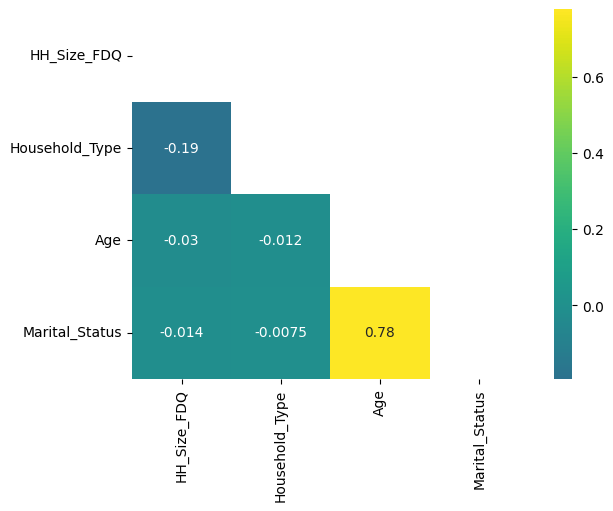

In [9]:
import numpy as np

corr = mdf.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    cmap='viridis',
    center=0,
    cbar=True,
    mask=mask,
    xticklabels=mdf.columns,
    yticklabels=mdf.columns,
)

In [ ]:
def merge_plot_heatmap(levels:list, cols:list, title:str) -> None:
    
    # Empty list to store the dataframes
    dfs = []
    
    # Load the data
    for df in levels:
        if df == 2:
            df2 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-2.parquet")
            df2.append(dfs)
        elif df == 3:
            df3 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-3.parquet")
            dfs.append(df3)
        elif df == 4:
            df4 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-4.parquet")
            dfs.append(df4)
        elif df == 7:
            df7 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-7.parquet")
            dfs.append(df7)
        elif df == 8:
            df8 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-8.parquet")
            dfs.append(df8)
        elif df == 11:
            df11 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-11.parquet")
            dfs.append(df11)
        elif df == 15:
            df15 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-15.parquet")
            dfs.append(df3)

    # Check the length
    if len(dfs) > 1:
        mdf = dfs[0]
        for df in dfs:
            mdf = mdf.join(other=df, on='FSU_Serial_No')
            

    # Filter features
    mdf = mdf[cols]
    corr = mdf.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Plot graph
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        cmap='viridis',
        center=0,
        cbar=True,
        mask=mask,
        xticklabels=pdf.columns,
        yticklabels=pdf.columns,
    )
    plt.title(f"{title} Correlation Matrix Heatmap)")
    plt.show()

    # Clear the memory
    for df in dfs:
        del df
    del mdf      

In [2]:
l2 =  [
'Relation_to_Head',
'Age',
'Marital_Status',
'Education_Level',
'Years_of_Education',
'Used_Internet_Last_30_Days',
]

l3 = [
    'Max_Income_Activity',
'Self_Employment_Source_Sector',
'Regular_Wage_Source_Sector',
'Casual_Labour_Source_Sector',
'Household_Type',
'Land_Ownership',
'Type_of_Dwelling_Unit',
'Ration_Card_Type',
'Benefitted_From_PMGKY',
]

l4 = [
    'Ration_Rice',
'Ration_Wheat',
'Ration_Coarse_Grain',
'Ration_Sugar',
'Ration_Pulses',
'Ration_Edible_Oil',
'Ration_Other_Food_Items',
'Online_Groceries',
'Online_Milk',
'Online_Vegetables',
'Online_Fresh_Fruits',
'Online_Dry_Fruits',
'Online_Egg_Fish_Meat',
'Online_Served_Processed_Food',
'Online_Packed_Processed_Food',
'Online_Other_Food_Items',
]

l7 = [
    'LPG_subsidy_received',
'LPG_subsidized_cylinders',
'Free_electricity',
'Total_textbooks',
'Free_school_bag_received',
'Ayushman_beneficiary',
'Medical_benefit_received',
'Online_purchase_fuel_light',
'Online_purchase_toilet_articles',
'Online_purchase_education',
'Online_purchase_medicine',
'Online_purchase_services',
]

l8 = ['Total_consumption_value_rs']

In [3]:
import findmyjoint as fmj

In [4]:
df1 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-01\data2\lev_01_mp.parquet")

In [9]:
df1.columns

['Survey_Name',
 'Year',
 'FSU_Serial_No',
 'Sector',
 'State',
 'NSS_Region',
 'District',
 'Stratum',
 'Sub_stratum',
 'Panel',
 'Sub_sample',
 'FOD_Sub_Region',
 'Sample_SU_No',
 'Sample_Sub_Division_No',
 'Second_Stage_Stratum_No',
 'Sample_Household_No',
 'Questionnaire_No',
 'Level',
 'Survey_Code',
 'Reason_for_Substitution_Code',
 'Multiplier']

In [11]:
df1['FSU_Serial_No'].n_unique()

791

In [14]:
df2 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-02\data2\lev_02_mp_clean.parquet")
                      

In [16]:
df2['FSU_Serial_No'].n_unique()

791

In [17]:
df1['FSU_Serial_No'] == df1['FSU_Serial_No']

FSU_Serial_No
bool
true
true
true
true
true
…
true
true
true


In [6]:
datasets = [df1, df2]

In [8]:
matrix = fmj.compare(datasets,)
print(matrix.head())

TypeError: All items in 'datasets' must be pandas DataFrames.

In [14]:
def load_clear(path, cols:list):
    path = path
    pdf = pl.read_parquet(path)
    pdf = pdf[cols]
    
    display(pdf.head(3))
    display(pdf.null_count())
    display(pdf.corr())
    del pdf

In [4]:
df2 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-02\data2\lev_02_mp_clean.parquet")

In [12]:
df2 = df2[l2]
df2.null_count()

Relation_to_Head,Age,Marital_Status,Education_Level,Years_of_Education,Used_Internet_Last_30_Days
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [18]:
df2c = df2.corr()
df2c

Relation_to_Head,Age,Marital_Status,Education_Level,Years_of_Education,Used_Internet_Last_30_Days
f64,f64,f64,f64,f64,f64
1.0,-0.60336,-0.60527,-0.07739,-0.101118,0.053235
-0.60336,1.0,0.778519,0.055919,0.170122,-0.173195
-0.60527,0.778519,1.0,0.003713,0.100222,-0.137359
-0.07739,0.055919,0.003713,1.0,0.764362,0.532441
-0.101118,0.170122,0.100222,0.764362,1.0,0.410427
0.053235,-0.173195,-0.137359,0.532441,0.410427,1.0


<Axes: >

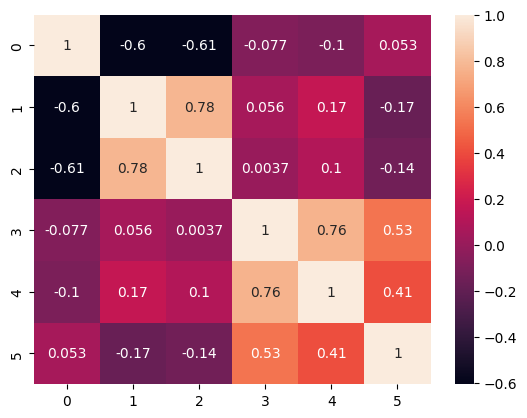

In [24]:
sns.heatmap(df2c, annot=True)

In [ ]:
df2cc = df2c.to_pandas()
df2cc

,Relation_to_Head,Age,Marital_Status,Education_Level,Years_of_Education,Used_Internet_Last_30_Days
0,1.000000,-0.603360,-0.605270,-0.077390,-0.101118,0.053235
1,-0.603360,1.000000,0.778519,0.055919,0.170122,-0.173195
2,-0.605270,0.778519,1.000000,0.003713,0.100222,-0.137359
3,-0.077390,0.055919,0.003713,1.000000,0.764362,0.532441
4,-0.101118,0.170122,0.100222,0.764362,1.000000,0.410427
5,0.053235,-0.173195,-0.137359,0.532441,0.410427,1.000000


<Axes: >

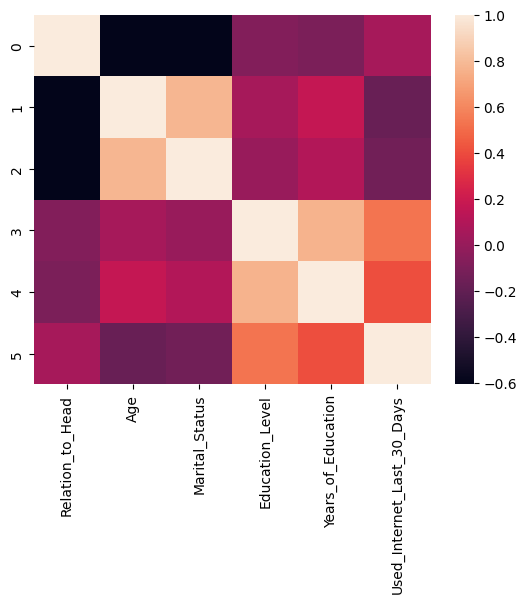

In [22]:
sns.heatmap(df2cc)

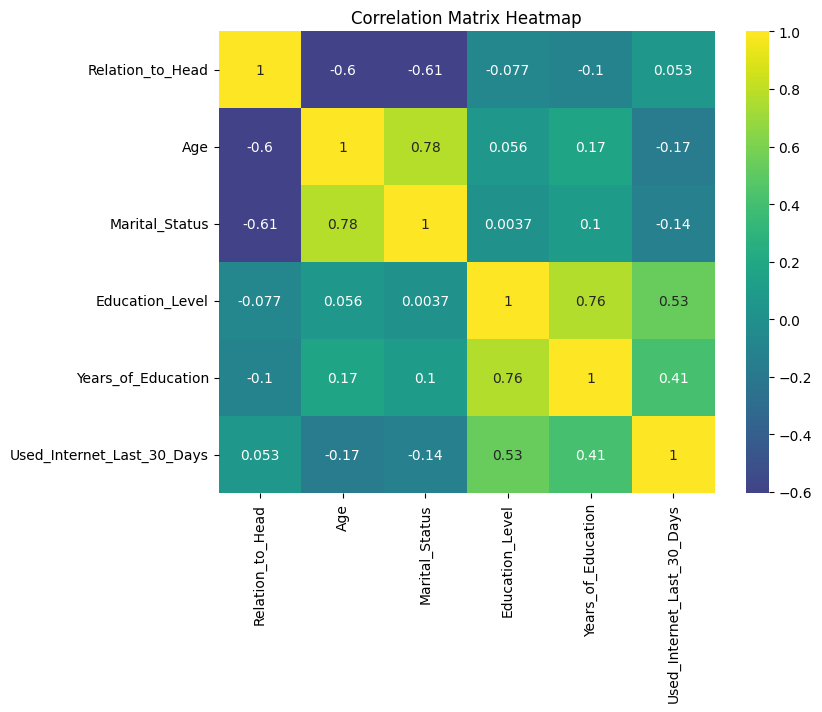

In [30]:
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df2cc, annot=True, cmap="viridis", center=0, cbar=True, xticklabels=df2cc.columns, yticklabels=df2cc.columns)

# Show the plot
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
# Compute correlation matrix
corr = df.corr().round(3)

# Melt into long format (pairwise list)
corr_melt = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # upper triangle only
corr_melt = corr_melt.stack().reset_index()
corr_melt.columns = ["Variable1", "Variable2", "Correlation"]

# Function to label correlation strength
def label_corr(value):
    if abs(value) >= 0.8:
        return "Very High"
    elif abs(value) >= 0.6:
        return "High"
    elif abs(value) >= 0.4:
        return "Moderate"
    elif abs(value) >= 0.2:
        return "Low"
    else:
        return "Very Low"

corr_melt["Category"] = corr_melt["Correlation"].apply(label_corr)

display(corr_melt)


,Variable1,Variable2,Correlation,Category
0,Relation_to_Head,Age,-0.934,Very High
1,Relation_to_Head,Marital_Status,-0.930,Very High
2,Relation_to_Head,Education_Level,-0.085,Very Low
3,Relation_to_Head,Years_of_Education,-0.220,Low
4,Relation_to_Head,Used_Internet_Last_30_Days,0.229,Low
5,Age,Marital_Status,0.970,Very High
6,Age,Education_Level,-0.199,Very Low
7,Age,Years_of_Education,-0.023,Very Low
8,Age,Used_Internet_Last_30_Days,-0.540,Moderate
9,Marital_Status,Education_Level,-0.247,Low


In [6]:
# lev 2
load_clear(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-02\data2\lev_02_mp_clean.parquet")

Schema([('Revisit_Status', Int32),
        ('FDQ_Original_Member', Int32),
        ('Multiplier', Int32),
        ('Meals_Usually_Taken_Per_Day', Int32),
        ('Meals_From_School', Int32),
        ('Meals_From_Employer', Int32),
        ('Meals_Other', Int32),
        ('Meals_On_Payment', Int32),
        ('Meals_At_Home', Int32),
        ('Used_Internet_Last_30_Days', Int32),
        ('Days_Away_From_Home_Last_30_Days', Int32),
        ('FSU_Serial_No', Int32),
        ('Relation_to_Head', Int32),
        ('Gender', Int32),
        ('Age', Int32),
        ('Marital_Status', Int32),
        ('Education_Level', Int32),
        ('Years_of_Education', Int32)])

In [7]:
# lev 03
load_clear(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-03\data2\lev_03_mp_clean.parquet")

Schema([('FSU_Serial_No', Int32),
        ('HH_Size_FDQ', Int32),
        ('Household_Type', Int32),
        ('Religion_of_HH_Head', Int32),
        ('Land_Ownership', Int32),
        ('Type_of_Land_Owned', Int32),
        ('Total_Area_Land_Owned_Acres', Int32),
        ('Energy_Source_Cooking', Int32),
        ('Energy_Source_Lighting', Int32),
        ('Dwelling_Unit_Exists', Int32),
        ('Type_of_Dwelling_Unit', Int32),
        ('Rent_Rate_Available_Rural', Int32),
        ('Multiplier', Int32),
        ('Self_Employment_Source_Sector', Int32),
        ('Regular_Wage_Source_Sector', Int32),
        ('Casual_Labour_Source_Sector', Int32),
        ('Ration_Card_Type', Int32),
        ('Engaged_in_Economic_Activity_Las', Int32),
        ('Max_Income_Activity', Int32),
        ('Benefitted_From_PMGKY', Int32)])

In [8]:
demographic_cols_02 = [
    'Relation_to_Head',
    'Age',
    'Marital_Status'
]

demographic_cols_03 = [
    'HH_Size_FDQ',
    'Household_Type',
    'Type_of_Dwelling_Unit',
]

In [9]:
income_cols_03 = [
    'Max_Income_Activity',
    'Self_Employment_Source_Sector',
    'Regular_Wage_Source_Sector',
    'Casual_Labour_Source_Sector',
]

In [10]:
l2 =  [
'Relation_to_Head',
'Age',
'Marital_Status',
'Education_Level',
'Years_of_Education',
'Used_Internet_Last_30_Days',
]

l3 = [
    'Max_Income_Activity',
'Self_Employment_Source_Sector',
'Regular_Wage_Source_Sector',
'Casual_Labour_Source_Sector',
'Household_Type',
'Land_Ownership',
'Type_of_Dwelling_Unit',
'Ration_Card_Type',
'Benefitted_From_PMGKY',
]

l4 = [
    'Ration_Rice',
'Ration_Wheat',
'Ration_Coarse_Grain',
'Ration_Sugar',
'Ration_Pulses',
'Ration_Edible_Oil',
'Ration_Other_Food_Items',
'Online_Groceries',
'Online_Milk',
'Online_Vegetables',
'Online_Fresh_Fruits',
'Online_Dry_Fruits',
'Online_Egg_Fish_Meat',
'Online_Served_Processed_Food',
'Online_Packed_Processed_Food',
'Online_Other_Food_Items',
]

l7 = [
    'LPG_subsidy_received',
'LPG_subsidized_cylinders',
'Free_electricity',
'Total_textbooks',
'Free_school_bag_received',
'Ayushman_beneficiary',
'Medical_benefit_received',
'Online_purchase_fuel_light',
'Online_purchase_toilet_articles',
'Online_purchase_education',
'Online_purchase_medicine',
'Online_purchase_services',
]

l8 = ['Total_consumption_value_rs']

